In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#1
df = pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
#2
#kadın-erkek sayısına bakalım
gender = df["gender"].value_counts()
gender

,count
gender,
female,518
male,482


Text(0, 0.5, 'Öğrenci Sayısı')

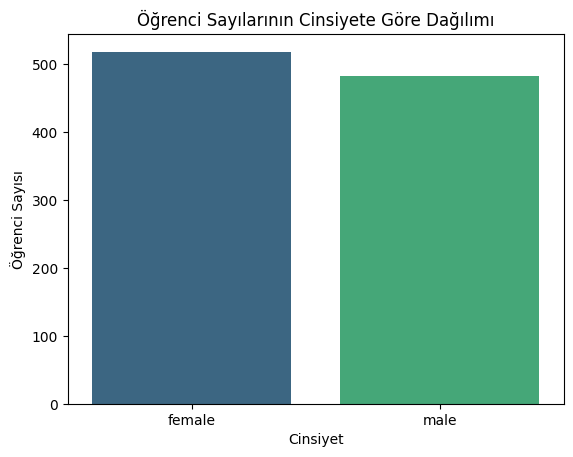

In [4]:
#3
#kadın-erkek sayısına histogram grafiği ile bakalım
sns.countplot(data=df, x='gender', hue='gender', palette='viridis', legend=False)

# Grafik başlığını ve eksen etiketlerini (labels) belirledik.
plt.title('Öğrenci Sayılarının Cinsiyete Göre Dağılımı')
plt.xlabel('Cinsiyet')
plt.ylabel('Öğrenci Sayısı')

In [5]:
#4
#race/ethnicity sütununda kaç farklı grup olduğuna bakalım

In [6]:
race = df["race/ethnicity"].value_counts()
race

,count
race/ethnicity,
group C,319
group D,262
group B,190
group E,140
group A,89


In [7]:
#5
#yukarıda bulduğumuzu görselleştirelim

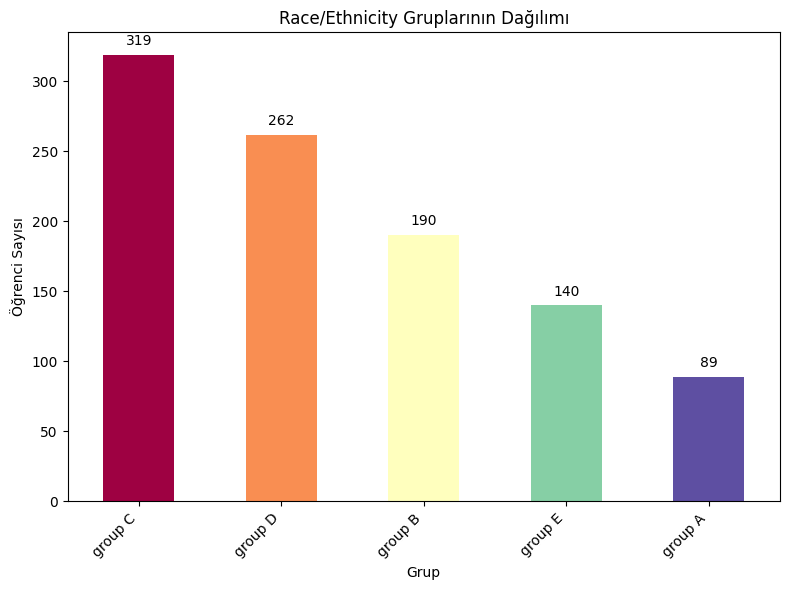

In [8]:
import numpy as np

plt.figure(figsize=(8, 6))                  # Grafik alanının boyutunu ayarlar.

# 1. GRAFİK ÇİZİMİ
# value_counts() ile sayım yapılıp, Pandas'ın plot() fonksiyonuyla çubuk grafik çizilir.
ax = df["race/ethnicity"].value_counts().plot(kind="bar", color=plt.cm.Spectral(np.linspace(0, 1, 5)))

# 2. BAŞLIK VE ETİKETLER
plt.title("Race/Ethnicity Gruplarının Dağılımı")
plt.xlabel("Grup")
plt.ylabel("Öğrenci Sayısı")
plt.xticks(rotation=45, ha='right') # X ekseni etiketlerinin çakışmasını önler.

# 3. ÇUBUKLARIN ÜZERİNE SAYI EKLEME (Annotation)
# Her çubuğu tek tek ziyaret ederek sayı değerini üzerine yazar.
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 10),
                textcoords='offset points')

# 5. SONLANDIRMA
plt.tight_layout() # Görsel düzenlemeyi otomatik ayarlar.
plt.show()

In [9]:
#6
#parental level of education sütunundaki eşsiz değerleri bulalım

In [10]:
unique_parent_edu = df["parental level of education"].unique()
print(unique_parent_edu)

["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']


In [11]:
df["parental level of education"].value_counts()

,count
parental level of education,
some college,226
associate's degree,222
high school,196
some high school,179
bachelor's degree,118
master's degree,59


In [12]:
#7
#lunch sütununda eşsiz değerlere ulaşalım

In [13]:
# lunch sütunundaki eşsiz değerlerin (benzersiz kategorilerin) listesini bulur.
unique_lunch = df["lunch"].unique()
print(unique_lunch)

['standard' 'free/reduced']


In [14]:
#8
#lunch türlerinde kaçar kişi olduğunu bulalım

In [15]:
# lunch sütunundaki her bir kategorinin kaçar kişi olduğunu (sıklığını) sayar.
lunch_counts = df['lunch'].value_counts()

print("Öğle Yemeği Türlerine Göre Öğrenci Sayıları:")
print(lunch_counts)

Öğle Yemeği Türlerine Göre Öğrenci Sayıları:
lunch
standard        645
free/reduced    355
Name: count, dtype: int64


In [16]:
df["test preparation course"].value_counts()

,count
test preparation course,
none,642
completed,358


In [17]:
#9
#gender sütunundaki değerler için ortalama math score, reading score, writing score değerlerini bulalım.
gender_means = df.groupby("gender")[["math score", "reading score", "writing score"]].mean()
print(gender_means)

        math score  reading score  writing score
gender                                          
female   63.633205      72.608108      72.467181
male     68.728216      65.473029      63.311203


In [18]:
#10
#race/ethnicity sütunundaki değerler için ortalama math score, reading score, writing score değerlerini bulalım.

race_means = df.groupby("race/ethnicity")[["math score", "reading score", "writing score"]].mean()
print(race_means)

                math score  reading score  writing score
race/ethnicity                                          
group A          61.629213      64.674157      62.674157
group B          63.452632      67.352632      65.600000
group C          64.463950      69.103448      67.827586
group D          67.362595      70.030534      70.145038
group E          73.821429      73.028571      71.407143


In [19]:
#11
#parental level of education sütunundaki değerler için ortalama math score, reading score, writing score değerlerini bulalım.
parent_edu_means = df.groupby("parental level of education")[["math score", "reading score", "writing score"]].mean()
print(parent_edu_means)

                             math score  reading score  writing score
parental level of education                                          
associate's degree            67.882883      70.927928      69.896396
bachelor's degree             69.389831      73.000000      73.381356
high school                   62.137755      64.704082      62.448980
master's degree               69.745763      75.372881      75.677966
some college                  67.128319      69.460177      68.840708
some high school              63.497207      66.938547      64.888268


In [20]:
#12
#lunch sütunundaki değerler için ortalama math score, reading score, writing score değerlerini bulalım.
lunch_means = df.groupby("lunch")[["math score", "reading score", "writing score"]].mean()
print(lunch_means)

              math score  reading score  writing score
lunch                                                 
free/reduced   58.921127      64.653521      63.022535
standard       70.034109      71.654264      70.823256


In [21]:
#13
#test preparation coursesütunundaki değerler için ortalama math score, reading score, writing score değerlerini bulalım.
prep_course_means = df.groupby("test preparation course")[["math score", "reading score", "writing score"]].mean()
print(prep_course_means)

                         math score  reading score  writing score
test preparation course                                          
completed                 69.695531      73.893855      74.418994
none                      64.077882      66.534268      64.504673
